In [2]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleLSTM:
    def __init__(self, input_dim, hidden_dim):
        # Initialize dimensions
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Initialize weights based on the PDF example
        self.Wf = np.array([[0.7], [0.5]])  # Forget gate weights
        self.bf = np.array([0.1])           # Forget gate bias

        self.Wi = np.array([[0.5], [0.5]])  # Input gate weights
        self.bi = np.array([0.1])           # Input gate bias

        self.Wc = np.array([[0.2], [0.3]])  # Candidate cell state weights
        self.bc = np.array([0.4])           # Candidate cell state bias

        self.Wo = np.array([[0.3], [0.9]])  # Output gate weights
        self.bo = np.array([0.2])           # Output gate bias

        # Output weights for prediction
        self.Wy = np.array([2.3])
        self.by = np.array([0.5])

        # Initialize states
        self.h = np.zeros((hidden_dim, 1))  # Hidden state
        self.c = np.zeros((hidden_dim, 1))  # Cell state

    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-x))

    def tanh(self, x):
        """Tanh activation function"""
        return np.tanh(x)

    def forward_step(self, x_t):
        """
        Forward pass for a single time step
        Args:
            x_t: Input at time t (scalar)
        Returns:
            h_t: Hidden state at time t
        """
        # Convert scalar input to column vector and combine with previous hidden state
        x = np.array([[x_t], [self.h[0, 0]]])

        # Step 1: Forget gate
        f_t = self.sigmoid(np.dot(self.Wf.T, x) + self.bf)

        # Step 2: Input gate
        i_t = self.sigmoid(np.dot(self.Wi.T, x) + self.bi)

        # Step 3: Candidate cell state
        c_tilde = self.tanh(np.dot(self.Wc.T, x) + self.bc)

        # Step 4: Cell state update
        self.c = f_t * self.c + i_t * c_tilde

        # Step 5: Output gate
        o_t = self.sigmoid(np.dot(self.Wo.T, x) + self.bo)

        # Step 6: Hidden state update
        self.h = o_t * self.tanh(self.c)

        return self.h

    def predict(self):
        """
        Make a prediction based on the current hidden state
        Returns:
            y_pred: Predicted value
        """
        y_pred = np.dot(self.Wy, self.h) + self.by
        return y_pred[0]

    def forward_sequence(self, sequence):
        """
        Process a sequence of inputs and return all hidden states and predictions
        Args:
            sequence: List of input values
        Returns:
            hidden_states: List of hidden states for each time step
            predictions: List of predictions for each time step
        """
        hidden_states = []
        predictions = []

        for x_t in sequence:
            h_t = self.forward_step(x_t)
            hidden_states.append(h_t.copy())
            predictions.append(self.predict())

        return hidden_states, predictions

In [3]:
# Initialize LSTM with parameters matching the example
input_dim = 1
hidden_dim = 1
lstm = SimpleLSTM(input_dim, hidden_dim)

# Set initial states to match the example
lstm.h = np.array([[0.0]])
lstm.c = np.array([[0.0]])

# Input sequence from the example
sequence = [1, 2, 3]

# Process sequence step by step and print detailed calculations
print("Step-by-Step LSTM Calculations:")
for t, x_t in enumerate(sequence):
    print(f"\nTime Step {t+1}, Input x_{t+1} = {x_t}")

    # Create input vector [x_t, h_{t-1}]
    x = np.array([[x_t], [lstm.h[0, 0]]])

    # Forget gate
    f_t = lstm.sigmoid(np.dot(lstm.Wf.T, x) + lstm.bf)
    print(f"1. Forget gate:")
    print(f"   f_t = sigmoid(W_f^T · [x_t, h_{{t-1}}] + b_f)")
    print(f"   f_t = sigmoid({lstm.Wf.T} · {[[x_t], [lstm.h[0, 0]]]} + {lstm.bf})")
    print(f"   f_t = {f_t[0,0]:.4f}")

    # Input gate
    i_t = lstm.sigmoid(np.dot(lstm.Wi.T, x) + lstm.bi)
    print(f"2. Input gate:")
    print(f"   i_t = sigmoid(W_i^T · [x_t, h_{{t-1}}] + b_i)")
    print(f"   i_t = sigmoid({lstm.Wi.T} · {[[x_t], [lstm.h[0, 0]]]} + {lstm.bi})")
    print(f"   i_t = {i_t[0,0]:.4f}")

    # Candidate cell state
    c_tilde = lstm.tanh(np.dot(lstm.Wc.T, x) + lstm.bc)
    print(f"3. Candidate cell state:")
    print(f"   c~_t = tanh(W_c^T · [x_t, h_{{t-1}}] + b_c)")
    print(f"   c~_t = tanh({lstm.Wc.T} · {[[x_t], [lstm.h[0, 0]]]} + {lstm.bc})")
    print(f"   c~_t = {c_tilde[0,0]:.4f}")

    # Cell state update
    c_prev = lstm.c.copy()
    lstm.c = f_t * lstm.c + i_t * c_tilde
    print(f"4. Cell state update:")
    print(f"   c_t = f_t * c_{{t-1}} + i_t * c~_t")
    print(f"   c_t = {f_t[0,0]:.4f} * {c_prev[0,0]:.4f} + {i_t[0,0]:.4f} * {c_tilde[0,0]:.4f}")
    print(f"   c_t = {lstm.c[0,0]:.4f}")

    # Output gate
    o_t = lstm.sigmoid(np.dot(lstm.Wo.T, x) + lstm.bo)
    print(f"5. Output gate:")
    print(f"   o_t = sigmoid(W_o^T · [x_t, h_{{t-1}}] + b_o)")
    print(f"   o_t = sigmoid({lstm.Wo.T} · {[[x_t], [lstm.h[0, 0]]]} + {lstm.bo})")
    print(f"   o_t = {o_t[0,0]:.4f}")

    # Hidden state update
    h_prev = lstm.h.copy()
    lstm.h = o_t * lstm.tanh(lstm.c)
    print(f"6. Hidden state update:")
    print(f"   h_t = o_t * tanh(c_t)")
    print(f"   h_t = {o_t[0,0]:.4f} * tanh({lstm.c[0,0]:.4f})")
    print(f"   h_t = {lstm.h[0,0]:.4f}")

Step-by-Step LSTM Calculations:

Time Step 1, Input x_1 = 1
1. Forget gate:
   f_t = sigmoid(W_f^T · [x_t, h_{t-1}] + b_f)
   f_t = sigmoid([[0.7 0.5]] · [[1], [0.0]] + [0.1])
   f_t = 0.6900
2. Input gate:
   i_t = sigmoid(W_i^T · [x_t, h_{t-1}] + b_i)
   i_t = sigmoid([[0.5 0.5]] · [[1], [0.0]] + [0.1])
   i_t = 0.6457
3. Candidate cell state:
   c~_t = tanh(W_c^T · [x_t, h_{t-1}] + b_c)
   c~_t = tanh([[0.2 0.3]] · [[1], [0.0]] + [0.4])
   c~_t = 0.5370
4. Cell state update:
   c_t = f_t * c_{t-1} + i_t * c~_t
   c_t = 0.6900 * 0.0000 + 0.6457 * 0.5370
   c_t = 0.3467
5. Output gate:
   o_t = sigmoid(W_o^T · [x_t, h_{t-1}] + b_o)
   o_t = sigmoid([[0.3 0.9]] · [[1], [0.0]] + [0.2])
   o_t = 0.6225
6. Hidden state update:
   h_t = o_t * tanh(c_t)
   h_t = 0.6225 * tanh(0.3467)
   h_t = 0.2076

Time Step 2, Input x_2 = 2
1. Forget gate:
   f_t = sigmoid(W_f^T · [x_t, h_{t-1}] + b_f)
   f_t = sigmoid([[0.7 0.5]] · [[2], [0.20758373501228553]] + [0.1])
   f_t = 0.8325
2. Input gate:
   

In [4]:
# Predict next value
next_value = lstm.predict()
print("\nFinal Prediction:")
print(f"ŷ_5 = W_y · h_4 + b_y")
print(f"ŷ_5 = {lstm.Wy[0]} · {lstm.h[0,0]:.4f} + {lstm.by[0]}")
print(f"ŷ_5 = {next_value:.4f}")




Final Prediction:
ŷ_5 = W_y · h_4 + b_y
ŷ_5 = 2.3 · 0.7406 + 0.5
ŷ_5 = 2.2034


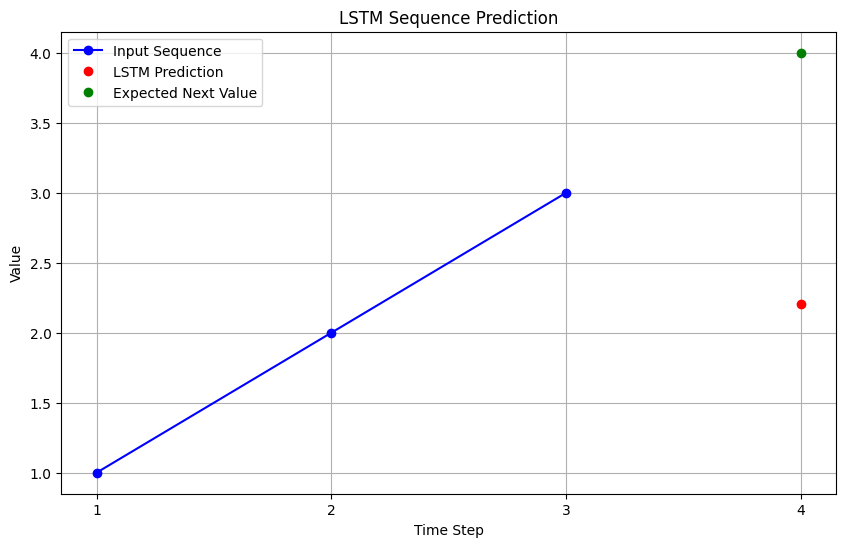

In [5]:
# Visualize the sequence and prediction
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sequence) + 1), sequence, 'bo-', label='Input Sequence')
plt.plot(len(sequence) + 1, next_value, 'ro', label='LSTM Prediction')
plt.plot(len(sequence) + 1, 4, 'go', label='Expected Next Value')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('LSTM Sequence Prediction')
plt.grid(True)
plt.legend()
plt.xticks(range(1, len(sequence) + 2))
plt.show()